Set up the warnings

# STAKEHOLDER-READY ANALYTICAL REPORT
Generated by Dan Baldwin - data analyst for Expectorating Wine, Inc.
For the review of Plato P. Fuddwinkle IVth - Chief Data Officer of Expectorating Wine, Inc.

The goal of this analysis is to review the different classes of Italian Wine for flavonoid, hue, and total phenols, and determine which model can best determine the ideal mix of these features in future Italian wine varieties. Included in this analysis will be a review of the initial data set, cleaning the data where appropriate, examining the relationship between all features in the dataset via correlation graph and pairplot. After that, three different classification models will be constructed via the usage of a classification function: Support Vector Machine, K Nearest Neighbor, and Decision Tree. 
The results of each model will then be produced, and analyzed to determine the most suitable model to refine in further iterations towards the stated goal. 

# The Report will be broken out as follows:
- Import Initial Libraries
- Import of Data
- Exploratory Data Analysis
- Performing Class Distribution and Feature Engineering
- Examining correlation of features versus target variable
- Data Pre-Processing and Selection
- Set up Train and Test Datasets
- Standardizing the Data
- Setting up the Estimators
- Creating Stacking Classifiers
- Fit Models
- Create Prediction Arrays
- Test Model Accuracy
- Model Selection and Justification
- Limitations and future work


In [130]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

Defining the accuracy of training and testing data given a model

In [131]:
def get_hyperparameters(X_train, X_test, y_train, y_test, model):
    return {
        "Test Set Accuracy": metrics.accuracy_score(y_test, model.predict(X_test_scaled)), 
        "Train Set Accuracy": metrics.accuracy_score(y_train, model.predict(X_train_scaled)),
        "Test Set Precision": metrics.precision_score(y_test, model.predict(X_test_scaled), average='weighted'),
        "Train Set Precision": metrics.precision_score(y_train, model.predict(X_train_scaled), average='weighted'),
        "Test Set Recall": metrics.recall_score(y_test, model.predict(X_test_scaled), average='weighted'),
        "Train Set Recall": metrics.recall_score(y_train, model.predict(X_train_scaled), average='weighted')
    }

## Import initial libraries

In [132]:
import scipy.optimize as pot
from sklearn import preprocessing, metrics

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns, pandas as pd, numpy as np, matplotlib.pyplot as plt
%matplotlib inline


## Import data from https://archive.ics.uci.edu/dataset/109/wine

In [133]:
wine_dataset_orig = pd.read_csv("C:/Users/alter/Desktop/Coursera_Desktop/Final Projects/Final Project 04_Sup_Mach_Learn_Classification/wine.data",names= ['Class', 'Alcohol', 'Malic acid', 'Ash',
         'Alcalinity of ash' ,'Magnesium', 'Total phenols',
         'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',     'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
         'Proline'])


# Data Description
## Key Features: Total Phenols, Nonflavanoid phenols, Flavanoids
## Target Class (y) variable: Class
Three different classification models will be constructed via the usage of a classification function: Support Vector Machine, K Nearest Neighbor, and Decision Tree.
First, the data will be analyzed, cleaned as appropriate, and then split into training and test sets.
Next, the X training and testing data will be scaled as appropriate.

Once the data is scaled, an initial test involving Logistic Regression will be run in order to confirm that the process workds. Then, a Support Vector Machine model will be tested to see if it can effectively predict the features per class, with interpretable results. Then a K-Nearest Neighbor and Decision Tree model will be developed and tested. 
The results (Accuracy, Precision, Recall, and F1 scores) will then be compared to see which models produce the best-fitted results. 

# Analytical Approach and Model Development
This analysis will review the different classes of Italian Wine for flavonoid, hue, and total phenols, and determine which model can best determine the ideal mix of these features in future Italian wine varieties. Included in this analysis will be a review of the initial data set, cleaning the data where appropriate, examining the relationship between all features in the dataset via correlation graph and pairplot. After that, the results of each model will then be produced, and analyzed to determine the most suitable model to refine in further iterations towards the stated goal. 

## Begin Exploratory Data Analysis (EDA) of dataset

In [134]:
print(wine_dataset_orig.shape)
wine_dataset_orig.info()

(178, 14)
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Prolin

The shape of the wine_dataset_orig is 178 rows, 14 columns. 
The dtypes of the dataset range between int64 and float64.

In [135]:
wine_dataset_orig.describe()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Reviewing the dataset through the .describe () function shows that the features (all columns other than 'Class') will need to be standardized after the training and test sets are established.

In [136]:
# Checking to see if there are any null values in the dataset
wine_dataset_orig.isnull().sum()

Class                           0
Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
dtype: int64

Confirmed there are no missing or null values in the dataset that need to be adjusted. The dataset is ready for train/test split, and then scaling. 

### Identifying the target variable (y) in the dataset: 'Class'.
All other variables ['Alcohol', 'Malic acid', 'Ash',
         'Alcalinity of ash' ,'Magnesium', 'Total phenols',
         'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',     'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
         'Proline']
         are considered as features (X).

In [137]:
wine_dataset_orig['Class'].unique()

array([1, 2, 3])

### Examining the correlation between each feature and the class variable, using a correlation heatmap and a pairplot. 
First, we will start off with a correlation of features heatmap.

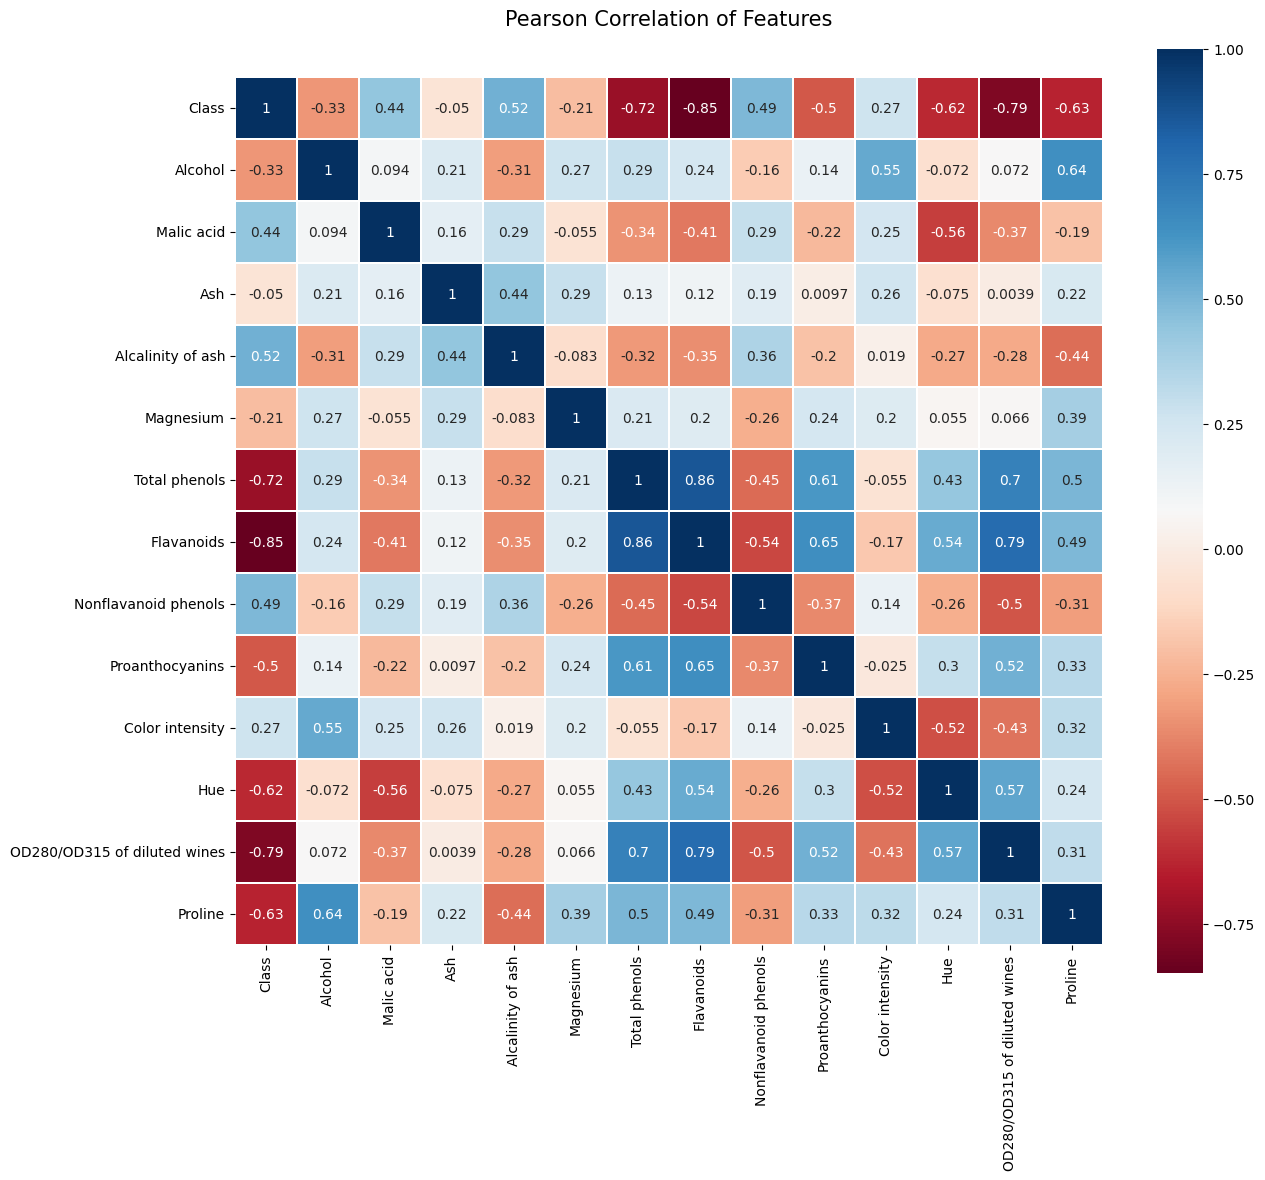

In [138]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(wine_dataset_orig.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=colormap, linecolor='white', annot=True)
plt.show()


The Correlation heatmap above shows strong relationships between the features 'Total phenols', 'Flavanoids', as well as the other features. These two features should be of emphasis in any models created. The nonflavanoid phenols should be included as a check against the other two features

Next, we will examine pairplot between pairs of features plus the target variable.

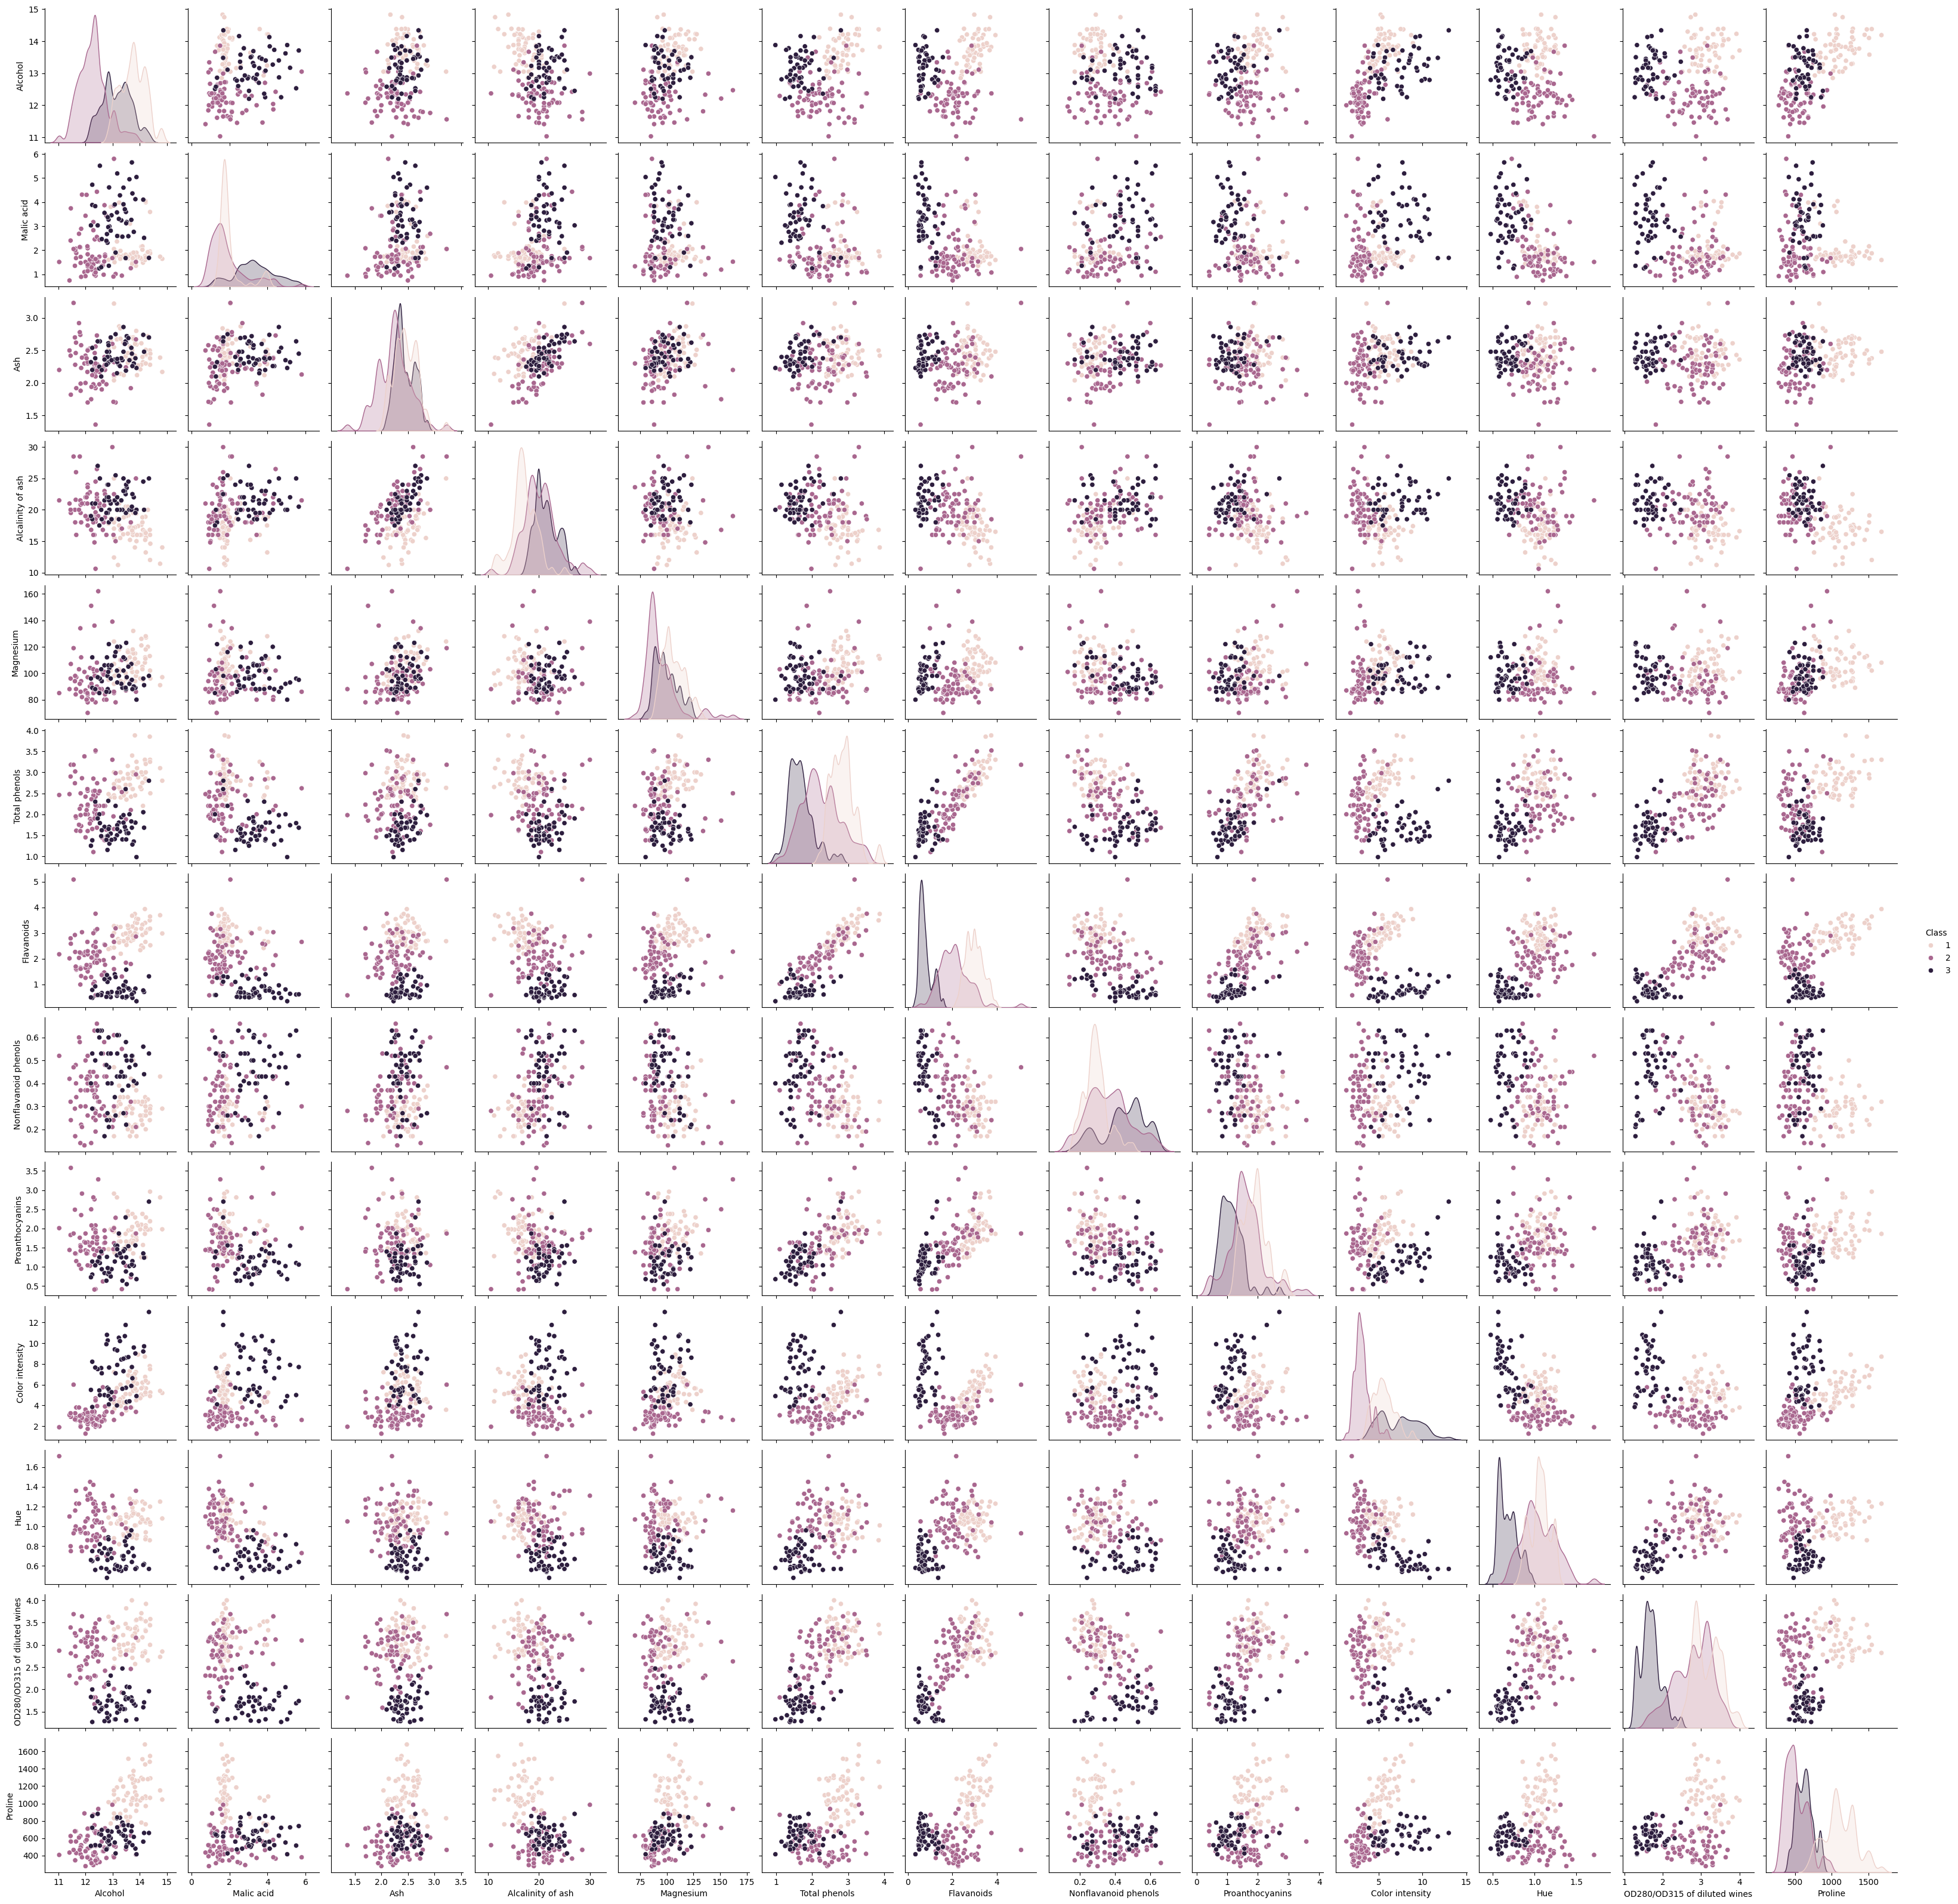

In [139]:
sns.pairplot(wine_dataset_orig, hue="Class", diag_kws={"bw": 0.2})

There appear to be the best distinct groupings between the features 'Total phenols', 'Flavanoids', and 'Nonflavanoid phenols', as predicted. Based on the patterns of groupings, the following models will be attempted: Support Vector Machines (SVM), K Nearest Neighbors (KNN), and Decision Trees (DeT). 

# Data Pre-Processing and Selection
### Setting and Examining the features (X variables) list

In [140]:
wine_features=list(wine_dataset_orig)
wine_features[1:]


['Alcohol',
 'Malic acid',
 'Ash',
 'Alcalinity of ash',
 'Magnesium',
 'Total phenols',
 'Flavanoids',
 'Nonflavanoid phenols',
 'Proanthocyanins',
 'Color intensity',
 'Hue',
 'OD280/OD315 of diluted wines',
 'Proline']

### Assign the class variables to y and feature variables to X

In [141]:
y,X=wine_dataset_orig[wine_features[0]], wine_dataset_orig.iloc[:, 1:]


### Set up train and test datasets

In [142]:
from sklearn.model_selection import train_test_split

In [143]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

In [144]:
print ('Initial Train set', X_train.shape,  y_train.shape)
print ('Initial Test set', X_test.shape,  y_test.shape)

Initial Train set (124, 13) (124,)
Initial Test set (54, 13) (54,)


### The data will need to be standardized

In [145]:
data_scaler = preprocessing.StandardScaler()
X_train_scaled = data_scaler.fit_transform(X_train)
X_test_scaled = data_scaler.fit_transform(X_test)


### Checking to see that the X data is standardized by checking the mean and standard deviation

In [146]:
# Checking Mean deviation for X_train
print("Mean deviation for X_train array:", X_train_scaled.mean(axis=0))

# Checking Mean deviation for X_test
print("Mean deviation for X_test array:", X_test_scaled.mean(axis=0))

Mean deviation for X_train array: [-1.70652023e-15  1.13932161e-16  1.33092462e-15 -2.82032462e-17
  2.33460205e-16  5.09001443e-16  1.14155996e-17  4.26853893e-16
 -4.23496363e-16  5.83762429e-16  5.28251278e-17  2.72183709e-16
  5.01391043e-17]
Mean deviation for X_test array: [-5.50948176e-15 -2.26156542e-16  5.76699182e-16  8.75842608e-16
 -3.35636868e-16 -1.58309579e-16  1.35693925e-16  7.23700935e-16
 -6.22958475e-16 -2.13820731e-16  3.61850467e-16  3.12507222e-16
 -1.64477485e-17]


In [147]:
# Checking Standard deviation for X_train
print("Standard deviation for X_train array:", X_train_scaled.std(axis=0))

# Checking Standard deviation for X_test
print("Standard deviation for X_test array:", X_test_scaled.std(axis=0))

Standard deviation for X_train array: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Standard deviation for X_test array: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Set up Estimators for future use

In [148]:
estimators = [('SVM', SVC(random_state=42)), ('KNN', KNeighborsClassifier()), ('DeT', DecisionTreeClassifier()), ('LoR', LogisticRegression())]
estimators


[('SVM', SVC(random_state=42)),
 ('KNN', KNeighborsClassifier()),
 ('DeT', DecisionTreeClassifier()),
 ('LoR', LogisticRegression())]

### Create stacking classifiers

In [149]:
clf_LoR = StackingClassifier( estimators=estimators, final_estimator= LogisticRegression(C=0.1), passthrough=False)
clf_LoR.fit(X_train_scaled, y_train)
clf_LoR

clf_SVM = StackingClassifier( estimators=estimators, final_estimator= SVC(C=1.0, kernel="linear"), passthrough=False)
clf_SVM.fit(X_train_scaled, y_train)
clf_SVM

clf_KNN = StackingClassifier( estimators=estimators, final_estimator= KNeighborsClassifier(n_neighbors=5), passthrough=False)
clf_KNN.fit(X_train_scaled, y_train)
clf_KNN

clf_DeT = StackingClassifier( estimators=estimators, final_estimator= DecisionTreeClassifier())
clf_DeT.fit(X_train_scaled, y_train)
clf_DeT


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('SVM', ...), ('KNN', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",DecisionTreeClassifier()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](3,)","[1,2,3]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[SVC(random_state=42), KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression()]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,DecisionTreeClassifier,DecisionTreeClassifier()


### Fit the models

In [150]:
wine_LoR = clf_LoR.fit(X_train_scaled, y_train)
wine_SVM = clf_SVM.fit(X_train_scaled, y_train)
wine_KNN = clf_KNN.fit(X_train_scaled, y_train)
wine_DeT = clf_DeT.fit(X_train_scaled, y_train)



### Create prediction arrays for the models

In [151]:
ypred_LoR=clf_LoR.predict(X_test_scaled)
ypred_LoR
# Checking to confirm the prediction array works



array([1, 1, 3, 1, 2, 1, 2, 3, 2, 3, 1, 3, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2,
       2, 3, 3, 3, 2, 2, 2, 1, 1, 2, 3, 1, 1, 1, 3, 3, 2, 3, 1, 2, 2, 2,
       3, 1, 2, 2, 3, 1, 2, 1, 1, 3])

In [152]:
ypred_SVM=clf_SVM.predict(X_test_scaled)

ypred_KNN=clf_KNN.predict(X_test_scaled)

ypred_DeT=clf_DeT.predict(X_test_scaled)

# Test model accuracy for LoR, SVM, KNN, and DeT

In [153]:
get_hyperparameters(X_train_scaled, X_test_scaled, y_train, y_test, wine_LoR)

{'Test Set Accuracy': 1.0,
 'Train Set Accuracy': 1.0,
 'Test Set Precision': 1.0,
 'Train Set Precision': 1.0,
 'Test Set Recall': 1.0,
 'Train Set Recall': 1.0}

In [154]:
get_hyperparameters(X_train_scaled, X_test_scaled, y_train, y_test, wine_SVM)

{'Test Set Accuracy': 1.0,
 'Train Set Accuracy': 1.0,
 'Test Set Precision': 1.0,
 'Train Set Precision': 1.0,
 'Test Set Recall': 1.0,
 'Train Set Recall': 1.0}

In [155]:
get_hyperparameters(X_train_scaled, X_test_scaled, y_train, y_test, wine_KNN)

{'Test Set Accuracy': 1.0,
 'Train Set Accuracy': 1.0,
 'Test Set Precision': 1.0,
 'Train Set Precision': 1.0,
 'Test Set Recall': 1.0,
 'Train Set Recall': 1.0}

In [156]:
get_hyperparameters(X_train_scaled, X_test_scaled, y_train, y_test, wine_DeT)


{'Test Set Accuracy': 0.9814814814814815,
 'Train Set Accuracy': 1.0,
 'Test Set Precision': 0.982716049382716,
 'Train Set Precision': 1.0,
 'Test Set Recall': 0.9814814814814815,
 'Train Set Recall': 1.0}

# KEY FINDINGS AND INSIGHTS
## Important Features: 
The important features for this model were "Flavanoids", "Nonflavanoid phenols", and "Total phenols".
## Prediction Patterns
The best prediction patterns based on the hyperparameters provided appear to be Support Vector Machines and Decision Trees, even with the evident overfitting. Those two models should be pursued for refining in further iterations.
## Classification outcomes
Using Class as the Target and then refining the Support Vector Machine and the Decision Tree models should result in models where the data's fit is improved. 

The results of the Support Vector Machine and Decision Tree models show that these two classification methods should be pursued in a second-round review. Because there are three features that have high relatability, scaling will have to be carefully applied. The predictive performance of these two models is significantly better than the Logistic Regression and KNearest Neighbors, as seen in the pairplot depictions of the data, and in the above hyperparameter results. 

# LIMITATIONS AND FUTURE WORK

## Limitations present due to data quality, class imbalance, model assumptions, and evaluation methods.
The biggest hurdle here was getting the features allocated to X scaled correctly. All four models are overfitting the data as evident in the hyperparameter results. The challenge here will be to figure out how to scale the data properly, and then amend the passthrough and weighting allocations in SVM and Decision Trees to get models that are better balanced between over- and under-fitting. The data quality wasn't an issue: there were no nulls, and the floats and integers in the respective features weren't a problem to work with. 
The evaluation method of pulling the hyperparameters by using the Training and Test data worked very well for identifying the best model in this iteration. 

For future improvements, it is my belief that we actually have an unbalanced class, and that perhaps the next iteration of models could take Random and Synthetic oversampling into account. Another option would be to pursue non-stacking of the models and instead re-run the training and test sets completely independent of each other. Other advanced techniques such as bagging or applying boosts (AdaBoost or Surrogate models) would be worth investigating as Next Steps. 